**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 8**
Regresión Lineal

---


Equipo 37

- Ricardo Saldaña Morales A01841000
- Carlos Rodrigo Salguero Alcántara A00833341
- Saldaña Jauregui Carlos Francisco A01639674
- Saul Salinas Nicolas A01840766


En esta actividad trabajarás con el archivo `diamonds_dataset.csv`, basado en un conjunto de datos sobre características de diamantes, disponible en el paquete ggplot2 de R y en repositorios públicos de análisis de datos.

Los datos fueron recopilados para analizar el precio de los diamantes en función de sus propiedades físicas y cualidades de corte, color y claridad. Los indicadores incluidos son:

- `carat`: Peso del diamante en quilates
- `cut`: Calidad del corte del diamante (Fair, Good, Very Good, Premium, Ideal)
- `color`: Color del diamante, de D (mejor) a J (peor)
- `clarity`: Claridad del diamante (I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF)
- `depth`: Profundidad total del diamante como porcentaje: z / mean(x, y)
- `table`: Ancho de la tabla del diamante como porcentaje de x
- `x`: Longitud en mm
- `y`: Ancho en mm
- `z`: Profundidad en mm
- `price`: Precio del diamante en dólares estadounidenses. Es la variable de salida o _target_

**NOTA IMPORTANTE:** Asegúrate de responder _explícitamente_ todos los cuestionamientos.


## Diamond Proportions

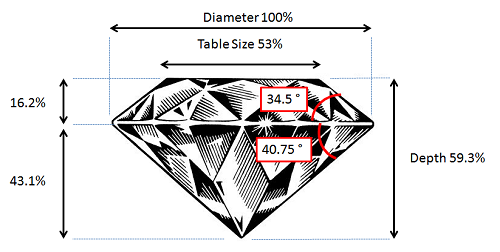

https://beyond4cs.com/shapes/round/ideal-proportions/



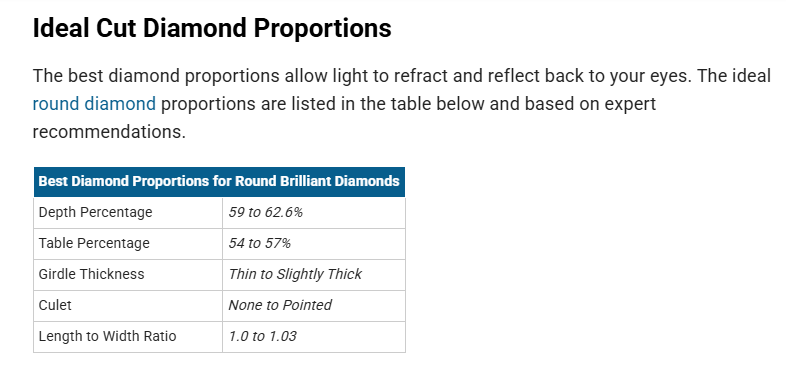

https://www.diamonds.pro/guides/diamond-proportion/

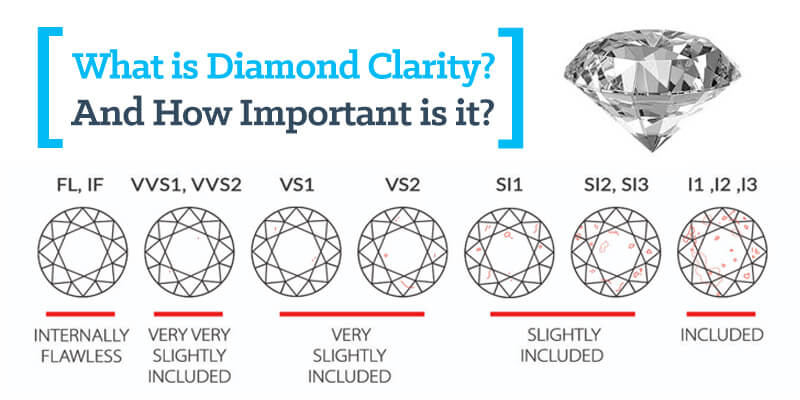

https://selectingadiamond.com/diamond-clarity/

In [ ]:
import warnings

warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd
import numpy as np

1. Descarga el archivo: `diamonds_dataset.csv` y guarda, en un dataframe (`diamonds_df`), todos sus registros.

- Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
- Determina la cantidad de valores únicos por columna.
- Verifica si alguna columna contiene valores faltantes.
- Si existen registros duplicados, elimínalos del dataframe y reinicia el índice para que se mantenga consecutivo.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
diamonds_df = pd.read_csv("/content/drive/MyDrive/MNA/Analítica y Ciencia de datos/diamonds_dataset.csv")
display(diamonds_df.head())

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335


In [ ]:
diamonds_df.info()

n_numeric = diamonds_df.select_dtypes(include=np.number).shape[1]
n_text = diamonds_df.select_dtypes(exclude=np.number).shape[1]
print(f"\nResumen de tipos -> numéricas: {n_numeric} | texto: {n_text}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53916 entries, 0 to 53915
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53916 non-null  float64
 1   cut      53916 non-null  object 
 2   color    53916 non-null  object 
 3   clarity  53916 non-null  object 
 4   depth    53916 non-null  float64
 5   table    53916 non-null  float64
 6   x        53916 non-null  float64
 7   y        53916 non-null  float64
 8   z        53916 non-null  float64
 9   price    53916 non-null  int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB

Resumen de tipos -> numéricas: 7 | texto: 3


In [ ]:
unique_counts = pd.DataFrame({
    "columna": diamonds_df.columns,
    "valores_únicos": diamonds_df.nunique().values,
})

print("Valores únicos por columna:")
display(unique_counts)

Valores únicos por columna:


,columna,valores_únicos
0,carat,271
1,cut,5
2,color,7
3,clarity,8
4,depth,184
5,table,127
6,x,550
7,y,549
8,z,371
9,price,11595


In [ ]:
missing = pd.DataFrame({
    "columna": diamonds_df.columns,
    "faltantes": diamonds_df.isnull().sum().values,
})

print("Valores faltantes por columna:")
display(missing)

Valores faltantes por columna:


,columna,faltantes
0,carat,0
1,cut,0
2,color,0
3,clarity,0
4,depth,0
5,table,0
6,x,0
7,y,0
8,z,0
9,price,0


In [ ]:
if missing["faltantes"].sum() == 0:
    print("\nNo hay valores faltantes en ninguna columna.")
else:
    cols_with_missing = missing.loc[missing["faltantes"] > 0, "columna"].tolist()
    print(f"\nColumnas con faltantes: {cols_with_missing}")


No hay valores faltantes en ninguna columna.


In [ ]:
n_dup_before = diamonds_df.duplicated().sum()
print(f"Registros duplicados antes de la limpieza: {n_dup_before:,}")
print(f"Filas totales antes de la limpieza:     {len(diamonds_df):,}")

Registros duplicados antes de la limpieza: 145
Filas totales antes de la limpieza:     53,916


In [ ]:
diamonds_df = diamonds_df.drop_duplicates().reset_index(drop=True)
display(diamonds_df.head())

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335


In [ ]:
n_dup_after = diamonds_df.duplicated().sum()
print(f"Registros duplicados después de la limpieza: {n_dup_after:,}")
print(f"Filas totales después de la limpieza: {len(diamonds_df):,}")
print(f"Filas eliminadas: {n_dup_before - n_dup_after:,}")

Registros duplicados después de la limpieza: 0
Filas totales después de la limpieza: 53,771
Filas eliminadas: 145


2. Obtén las estadísticas descriptivas, separando las variables numéricas y las categóricas. De estas últimas incluye las tablas de frecuencia.

- Para las variables numéricas genera histogramas y boxplots para explorar la distribución y la dispersión.
- Para las variables categóricas utiliza diagramas de barras para visualizar la frecuencia de cada categoría.


In [ ]:
print("Estadísticas descriptivas (variables numéricas):")
display(diamonds_df.describe().round(2))

Estadísticas descriptivas (variables numéricas):


,carat,depth,table,x,y,z,price
count,53771.00,53771.00,53771.00,53771.00,53771.00,53771.00,53771.00
mean,0.80,61.75,57.46,5.73,5.73,3.54,3930.32
std,0.47,1.43,2.23,1.12,1.14,0.70,3984.69
min,0.20,43.00,43.00,3.73,3.68,1.07,326.00
25%,0.40,61.00,56.00,4.71,4.72,2.91,951.00
50%,0.70,61.80,57.00,5.70,5.71,3.53,2401.00
75%,1.04,62.50,59.00,6.54,6.54,4.03,5323.50
max,4.50,79.00,95.00,10.23,58.90,31.80,18823.00


In [ ]:
print("Estadísticas descriptivas (variables categóricas):")
display(diamonds_df.describe(include=["object"]).T)

Estadísticas descriptivas (variables categóricas):


,count,unique,top,freq
cut,53771,5,Ideal,21485
color,53771,7,G,11254
clarity,53771,8,SI1,13030


In [ ]:
cat_cols = diamonds_df.select_dtypes(include=["object"]).columns
print("Tablas de frecuencia (variables categóricas):")

for col in cat_cols:
    freq = (
        diamonds_df[col]
        .value_counts()
        .rename_axis(col)
        .reset_index(name="frecuencia")
    )

    freq["porcentaje (%)"] = (freq["frecuencia"] / len(diamonds_df) * 100).round(2)

    print(f"\n--- {col} ---")
    display(freq)

Tablas de frecuencia (variables categóricas):

--- cut ---


,cut,frecuencia,porcentaje (%)
0,Ideal,21485,39.96
1,Premium,13737,25.55
2,Very Good,12065,22.44
3,Good,4888,9.09
4,Fair,1596,2.97



--- color ---


,color,frecuencia,porcentaje (%)
0,G,11254,20.93
1,E,9776,18.18
2,F,9517,17.70
3,H,8266,15.37
4,D,6753,12.56
5,I,5404,10.05
6,J,2801,5.21



--- clarity ---


,clarity,frecuencia,porcentaje (%)
0,SI1,13030,24.23
1,VS2,12225,22.74
2,SI2,9140,17.00
3,VS1,8155,15.17
4,VVS2,5056,9.40
5,VVS1,3646,6.78
6,IF,1784,3.32
7,I1,735,1.37


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
PRIMARY   = "#1F4E5F"
SECONDARY = "#C44E52"
ACCENT    = "#DD8452"
NEUTRAL   = "#6B7B8C"

In [ ]:
CATEG_PALETTE = [
    "#1F4E5F", "#DD8452", "#55876B", "#C44E52", "#8172B3",
    "#937860", "#5B8CA8", "#B0A160", "#A65C5C", "#6B7B8C",
]

In [ ]:
SEQ_CMAP = sns.light_palette(PRIMARY, as_cmap=True)
DIV_CMAP = sns.diverging_palette(15, 200, s=75, l=45, as_cmap=True)

In [ ]:
color_order = ["D", "E", "F", "G", "H", "I", "J"]
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

In [ ]:
NUM_LABELS = {
    "carat": "Quilates (ct)",
    "depth": "Profundidad (%)",
    "table": "Mesa (%)",
    "x": "Longitud x (mm)",
    "y": "Ancho y (mm)",
    "z": "Profundidad z (mm)",
    "price": "Precio (USD)",
}

In [ ]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#CCCCCC",
    "axes.titleweight": "bold",
    "axes.titlecolor": "#222222",
    "axes.labelcolor": "#333333",
    "axes.labelweight": "medium",
    "font.family": "DejaVu Sans",
    "grid.color": "#E8E8E8",
    "figure.dpi": 110,
})

In [ ]:
num_cols = diamonds_df.select_dtypes(include=[np.number]).columns.tolist()
n = len(num_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))

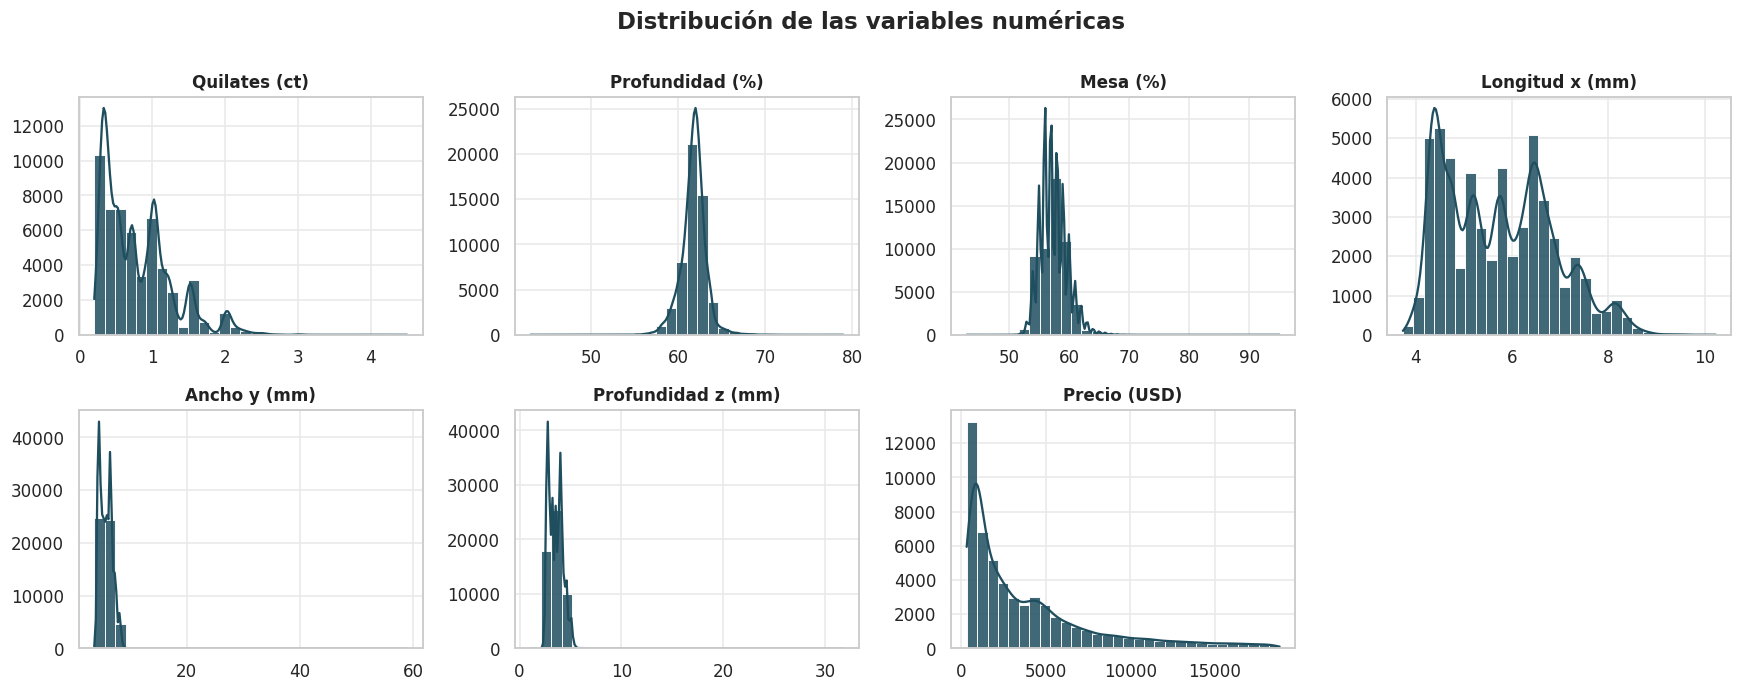

In [ ]:

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, num_cols):
    sns.histplot(
        diamonds_df[col], bins=30, kde=True,
        color=PRIMARY, edgecolor="white", alpha=0.85, ax=ax,
    )

    ax.set_title(NUM_LABELS.get(col, col), fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle(
    "Distribución de las variables numéricas",
    fontsize=15, fontweight="bold",
)

fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [ ]:
num_cols = diamonds_df.select_dtypes(include=[np.number]).columns.tolist()
n = len(num_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))

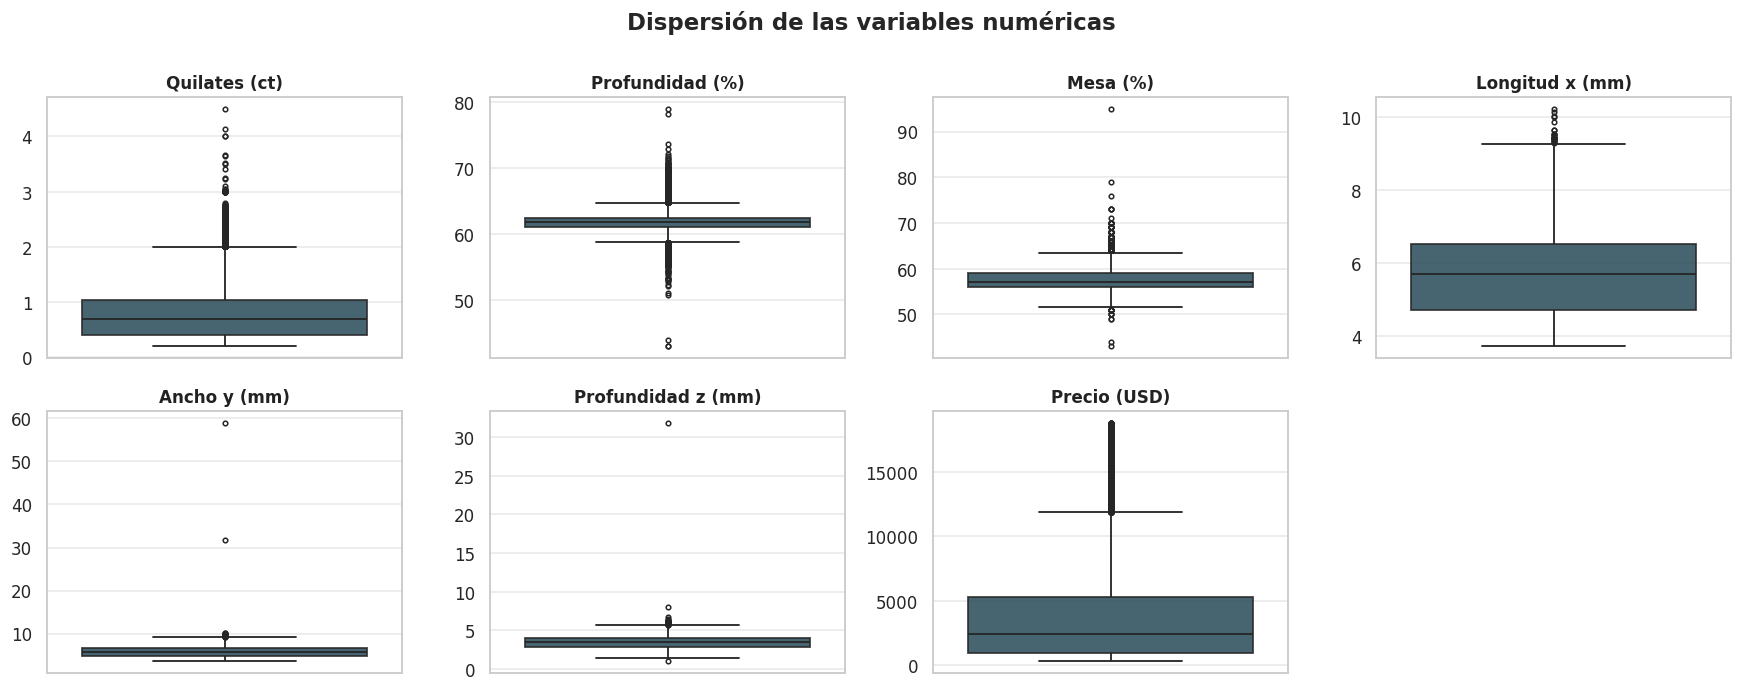

In [ ]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, num_cols):
    sns.boxplot(
        y=diamonds_df[col], color=PRIMARY, fliersize=3, linewidth=1.2,
        boxprops=dict(alpha=0.85), ax=ax,
    )

    ax.set_title(NUM_LABELS.get(col, col), fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle(
    "Dispersión de las variables numéricas",
    fontsize=15, fontweight="bold",
)

fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [ ]:
cat_config = [
    ("cut", cut_order, "Calidad de corte"),
    ("color", color_order, "Color"),
    ("clarity", clarity_order, "Claridad"),
]

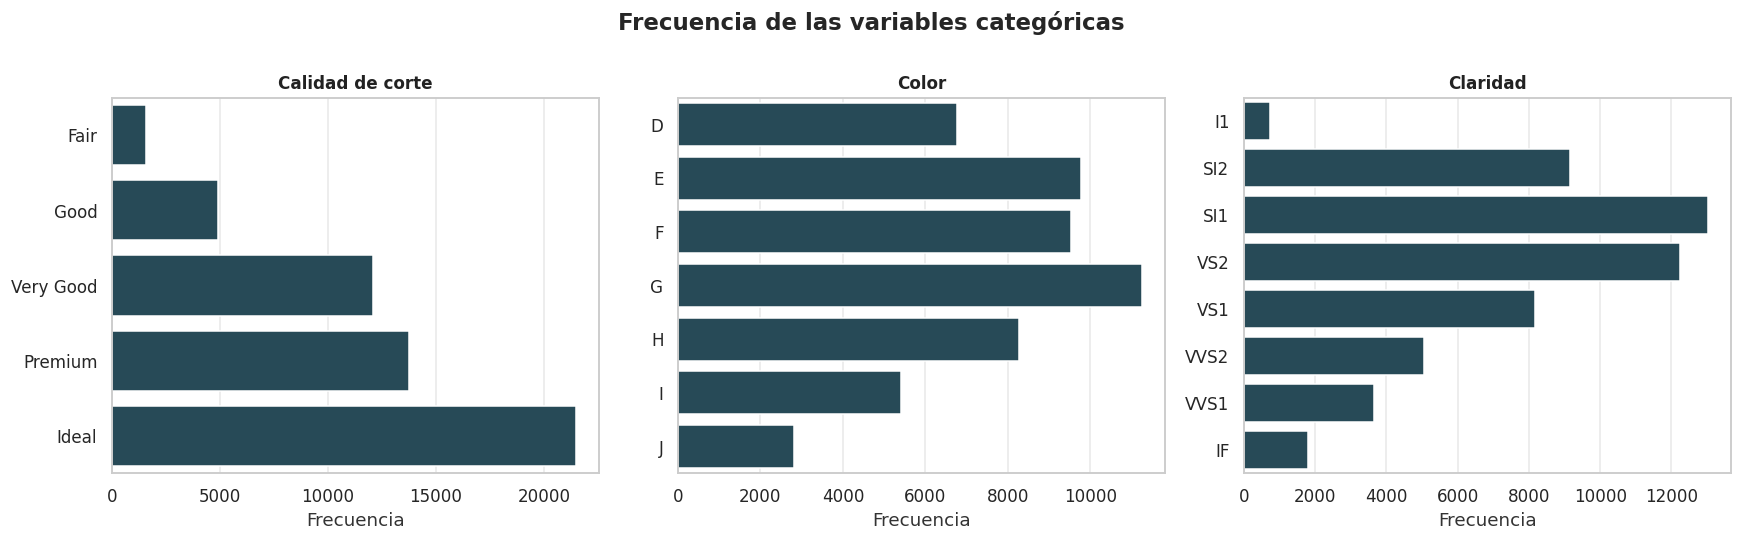

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, order, title) in zip(axes, cat_config):
    sns.countplot(
        y=col, data=diamonds_df, order=order,
        color=PRIMARY, ax=ax,
    )

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("")

fig.suptitle(
    "Frecuencia de las variables categóricas",
    fontsize=15, fontweight="bold",
)

fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

3. Explora relaciones bivariadas en el conjunto de datos mediante gráficos:

- Boxplots que muestren la distribución del precio para cada categoría de color, asegurándose de que las categorías se muestren en el orden de calidad de diamante de mejor a peor: D, E, F, G, H, I, J.
- ¿La tendencia de los precios se comporta como esperabas? Identifica si alguna otra variable podría estar influyendo en la tendencia observada por color y comenta tus observaciones.
- Gráfico de dispersión del precio frente al peso de los diamantes, coloreando los puntos según la categoría de calidad del corte.
- ¿Qué relación se observa entre el peso del diamante y su precio según la calidad del corte?


In [ ]:
print("Orden de color (mejor a peor):", " -> ".join(color_order))

Orden de color (mejor a peor): D -> E -> F -> G -> H -> I -> J


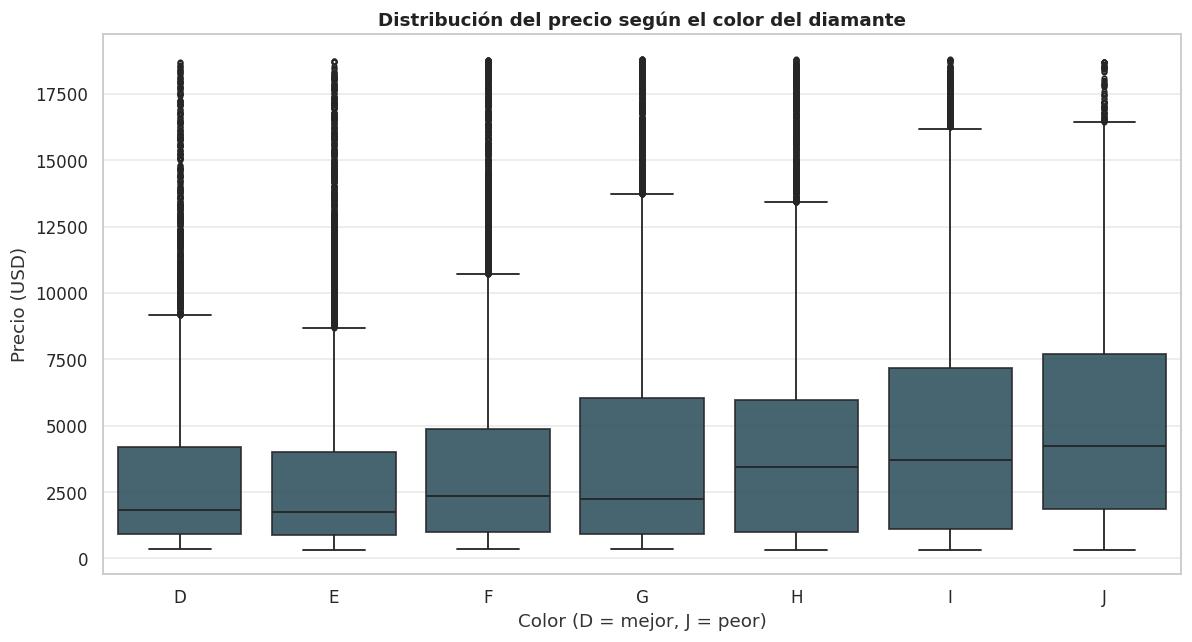

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    x="color", y="price", data=diamonds_df, order=color_order,
    color=PRIMARY, fliersize=3, linewidth=1.2,
    boxprops=dict(alpha=0.85), ax=ax,
)

ax.set_title("Distribución del precio según el color del diamante")
ax.set_xlabel("Color (D = mejor, J = peor)")
ax.set_ylabel("Precio (USD)")

plt.tight_layout()
plt.show()

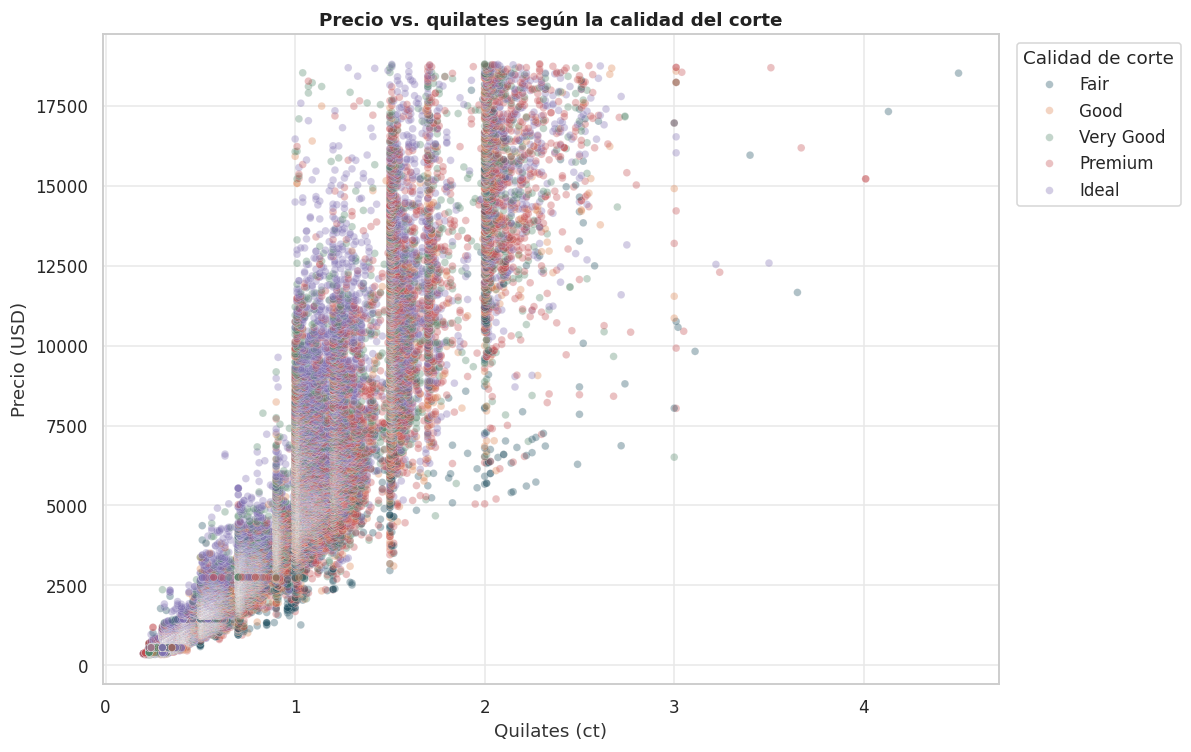

In [ ]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(
    x="carat", y="price", hue="cut", data=diamonds_df,
    hue_order=cut_order, palette=CATEG_PALETTE[:5],
    alpha=0.35, edgecolor="white", linewidth=0.2, s=25, ax=ax,
)

ax.set_title("Precio vs. quilates según la calidad del corte")
ax.set_xlabel("Quilates (ct)")
ax.set_ylabel("Precio (USD)")
ax.legend(title="Calidad de corte", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Respuestas — sección 3**

**Precio por color (D → J):** En general, los colores mejores (D, E, F) presentan medianas de precio más altas que los peores (I, J), lo cual es coherente con la escala de calidad del diamante. Sin embargo, la tendencia no es perfectamente monótona en todos los niveles y existe amplio solapamiento entre categorías, porque el color no actúa solo: variables como **quilates (`carat`)**, **corte (`cut`)** y **claridad (`clarity`)** también influyen en el precio y mezclan el efecto observable por color.

**Quilates vs. precio según corte:** Se observa una relación positiva y claramente no lineal entre `carat` y `price`: a mayor peso, mayor precio, con aceleración en diamantes grandes. Al colorear por `cut`, las categorías de mejor corte (**Ideal** y **Premium**) tienden a ubicarse por encima del resto para un mismo rango de quilates, mientras que **Fair** y **Good** muestran precios más bajos. Esto indica que el peso explica gran parte de la variación, pero la calidad del corte modula el precio final.


4. Dibuja un mapa de calor con la matriz de correlación para las variables numéricas del conjunto de datos.

- Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
- Analiza la correlación entre los predictores (excluyendo `price`), identifica si un único predictor captura información que también está presente en varios otros y elimina los predictores redundantes para simplificar la complejidad de los modelos que construirás más adelante.
- Vuelve a generar el mapa de calor para verificar que ya no queden predictores altamente correlacionados.


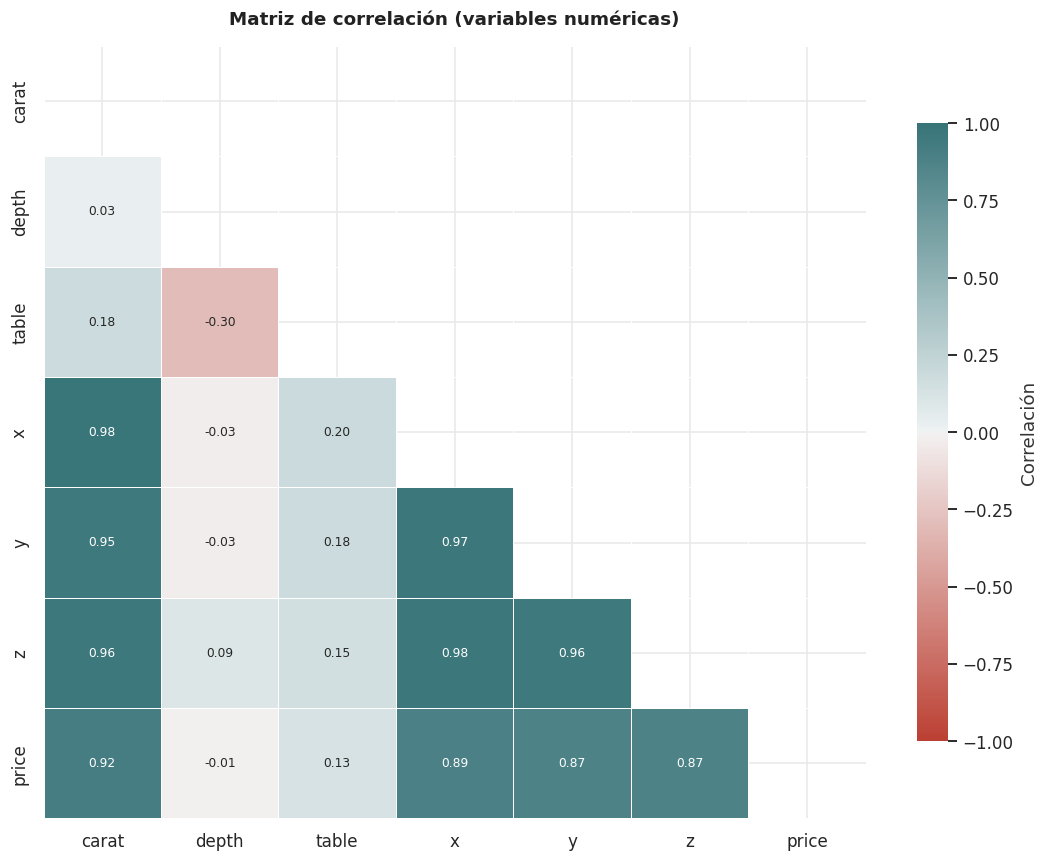

In [ ]:
corr_matrix = diamonds_df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f", annot_kws={"size": 8},
    cmap=DIV_CMAP, center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Correlación"}, ax=ax,
)

ax.set_title("Matriz de correlación (variables numéricas)", pad=14)
plt.tight_layout()
plt.show()

In [ ]:
cols = corr_matrix.columns
high_corr = []
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.9:
            high_corr.append({
                "variable_1": cols[i],
                "variable_2": cols[j],
                "correlación": round(r, 4),
            })

df_high_corr = pd.DataFrame(high_corr)
print(f"Pares con |correlación| > 0.9: {len(df_high_corr)}")
display(df_high_corr)


Pares con |correlación| > 0.9: 7


,variable_1,variable_2,correlación
0,carat,x,0.9781
1,carat,y,0.9542
2,carat,z,0.9612
3,carat,price,0.9218
4,x,y,0.9748
5,x,z,0.9754
6,y,z,0.9566


In [ ]:
diamonds_df = diamonds_df.drop(columns=['x', 'y', 'z'])

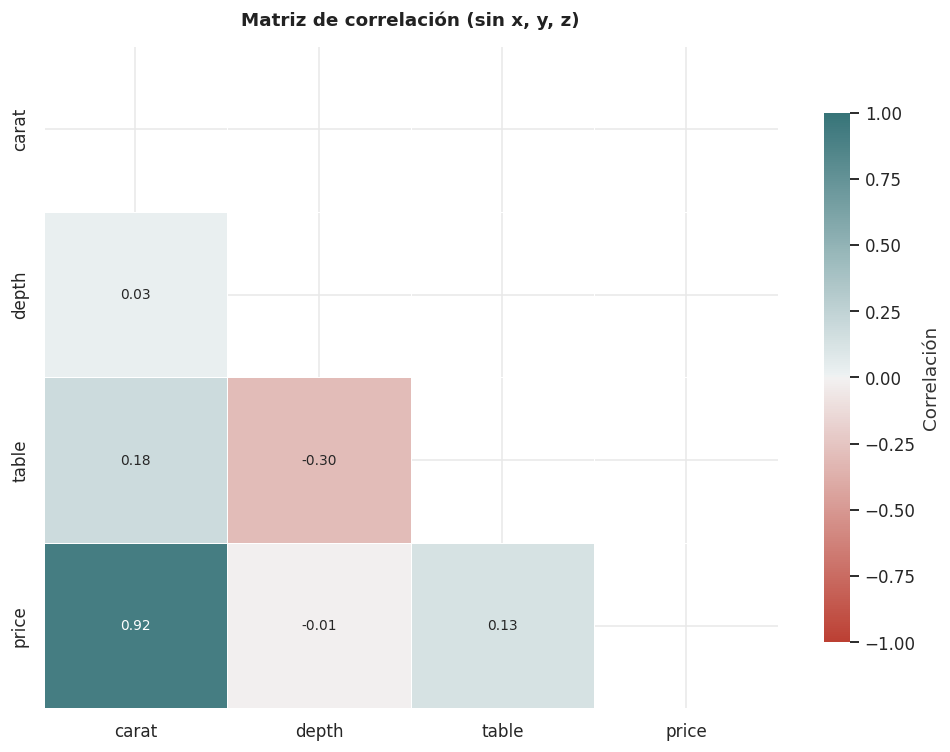

In [ ]:
corr_matrix_new = diamonds_df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr_matrix_new, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix_new, mask=mask, annot=True, fmt=".2f", annot_kws={"size": 9},
    cmap=DIV_CMAP, center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Correlación"}, ax=ax,
)

ax.set_title("Matriz de correlación (sin x, y, z)", pad=14)
plt.tight_layout()
plt.show()

**Respuestas — sección 4**

Los pares con correlación superior a 0.9 muestran que **`carat`** está fuertemente relacionado con las dimensiones físicas **`x`**, **`y`** y **`z`**, y también con **`price`**. Además, `x`, `y` y `z` están casi perfectamente correlacionadas entre sí.

Al analizar solo los predictores (excluyendo `price`), **`carat` concentra la información de tamaño** que también aportan `x`, `y` y `z`. Por ello se eliminaron estas tres dimensiones para reducir redundancia y multicolinealidad sin perder la señal principal del tamaño del diamante.

Tras eliminar `x`, `y` y `z`, el mapa de calor actualizado confirma que ya no quedan pares de predictores con correlación alta; la correlación máxima entre predictores es baja y el conjunto queda más apto para los modelos lineales posteriores.


5. Construye un modelo de regresión simple utilizando únicamente la variable predictora que tenga la mayor correlación con `price`. Para ello:

- Asigna esta variable a `X` y `price` a `y` y divide el conjunto de datos en entrenamiento y prueba (80:20), usando `random_state=1` para garantizar reproducibilidad.
- Entrena un modelo con `LinearRegression()` de scikit-learn y evalúalo en el conjunto de prueba utilizando las métricas `RMSE` (Root Mean Squared Error) y `R²` (coeficiente de determinación).
- Añade los valores obtenidos a un dataframe de resultados, que incluya el nombre del modelo (_Baseline_) y una columna para cada métrica.
- Muestra la ecuación de la regresión lineal utilizando el intercepto y el coeficiente asociado al predictor. La ecuación debe tener la forma:
  > `price = intercepto + coeficiente × predictor`


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
best_predictor = (
    diamonds_df.drop(columns=["price"])
    .select_dtypes(include=[np.number])
    .corrwith(diamonds_df["price"])
    .abs()
    .idxmax()
)
print(f"Predictor con mayor correlación con price: {best_predictor}")


Predictor con mayor correlación con price: carat


In [ ]:
X = diamonds_df[[best_predictor]]
y = diamonds_df["price"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=1
)

In [ ]:
model_base = LinearRegression()
model_base.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_base = model_base.predict(X_test)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)

In [ ]:
def show_results(df: pd.DataFrame, title: str = "Comparación de modelos"):
    """
    Shows the results of the models in a dataframe.

    Args:
        df: pd.DataFrame with the results of the models
        title: str with the title of the dataframe

    Returns:
        None
    """

    out = df.copy()
    out["RMSE"] = out["RMSE"].round(2)
    out["R2"] = out["R2"].round(4)
    out = out.rename(columns={"Model": "Modelo", "R2": "R²"})

    print(title)
    display(out[["Modelo", "RMSE", "R²"]])

In [ ]:
results = pd.DataFrame([{
    "Model": "Baseline",
    "RMSE": rmse_base,
    "R2": r2_base,
}])

show_results(results, "Resultados — modelo Baseline")
print(
    f"\nEcuación: price = {model_base.intercept_:.2f} + "
    f"{model_base.coef_[0]:.2f} × {best_predictor}"
)


Resultados — modelo Baseline


,Modelo,RMSE,R²
0,Baseline,1532.44,0.8462



Ecuación: price = -2276.79 + 7792.73 × carat


6. Utiliza todas las variables como predictoras para crear un segundo modelo:

- Haz la asignación correspondiente en `X` y `y` y divide en entrenamiento y prueba usando la misma configuración del ejercicio anterior.
- Prepara un transformador, denominado `preprocessing`, para aplicar escalamiento robusto a los predictores numéricos y codificación ordinal a los categóricos. Asegúrate de respetar el orden correcto de cada categoría, tal como se indica en la descripción de las variables.
- Construye un pipeline que combine el transformador creado con un modelo de regresión lineal.
- Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo _Ordinal_Robust_.


In [ ]:
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
X_full = diamonds_df.drop(columns=['price'])
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
  X_full, y, test_size=0.2, random_state=1
)

In [ ]:
cut_cats = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_cats = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_cats = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
num_cols = ['carat', 'depth', 'table']

In [ ]:
preprocessing = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat_cut', OrdinalEncoder(categories=[cut_cats]), ['cut']),
        ('cat_color', OrdinalEncoder(categories=[color_cats]), ['color']),
        ('cat_clarity', OrdinalEncoder(categories=[clarity_cats]), ['clarity'])
    ]
)

In [ ]:
pipeline_ordinal = Pipeline(steps=[
    ('preprocessor', preprocessing),
    ('regressor', LinearRegression())
])

In [ ]:
pipeline_ordinal.fit(X_train_f, y_train_f)
y_pred_ord = pipeline_ordinal.predict(X_test_f)

In [ ]:
results.loc[len(results)] = {
    'Model': 'Ordinal_Robust',
    'RMSE': np.sqrt(mean_squared_error(y_test_f, y_pred_ord)),
    'R2': r2_score(y_test_f, y_pred_ord)
}

In [ ]:
show_results(results)

Comparación de modelos


,Modelo,RMSE,R²
0,Baseline,1532.44,0.8462
1,Ordinal_Robust,1216.82,0.9030


7. Prepara otro transformador, llamado `preprocessing2`, que aplique escalamiento Min-Max a los predictores numéricos y codificación one-hot a los categóricos, asegurando `drop='first'` para prevenir multicolinealidad en las variables dummies generadas.

- Construye otro pipeline utilizando este nuevo transformador y, a continuación, entrena y evalúa el modelo.
- Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo _OHE_MinMax_.


In [ ]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

In [ ]:
preprocessing2 = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), ['cut', 'color', 'clarity'])
    ]
)

In [ ]:
pipeline_ohe = Pipeline(steps=[
    ('preprocessor', preprocessing2),
    ('regressor', LinearRegression())
])

In [ ]:
pipeline_ohe.fit(X_train_f, y_train_f)
y_pred_ohe = pipeline_ohe.predict(X_test_f)

In [ ]:
results.loc[len(results)] = {
    'Model': 'OHE_MinMax',
    'RMSE': np.sqrt(mean_squared_error(y_test_f, y_pred_ohe)),
    'R2': r2_score(y_test_f, y_pred_ohe)
}

In [ ]:
show_results(results)

Comparación de modelos


,Modelo,RMSE,R²
0,Baseline,1532.44,0.8462
1,Ordinal_Robust,1216.82,0.9030
2,OHE_MinMax,1142.52,0.9145


8. Modifica el pipeline anterior para emplear regresión polinomial de segundo grado y evalúa si esto mejora el ajuste del modelo.

- Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo _PolynomialDegree2_.


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessing2),
    ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
    ('regressor', LinearRegression())
])

In [ ]:
pipeline_poly.fit(X_train_f, y_train_f)
y_pred_poly = pipeline_poly.predict(X_test_f)

In [ ]:
results.loc[len(results)] = {
    'Model': 'PolynomialDegree2',
    'RMSE': np.sqrt(mean_squared_error(y_test_f, y_pred_poly)),
    'R2': r2_score(y_test_f, y_pred_poly)
}

In [ ]:
show_results(results)

Comparación de modelos


,Modelo,RMSE,R²
0,Baseline,1532.44,0.8462
1,Ordinal_Robust,1216.82,0.9030
2,OHE_MinMax,1142.52,0.9145
3,PolynomialDegree2,989.57,0.9359


9. Ordena el dataframe de resultados según el `R²`, de manera que el modelo con mejor desempeño aparezca primero.

- Para dicho modelo, crea un gráfico de dispersión de los valores reales frente a los predichos, e incluye una línea diagonal de referencia para indicar una predicción perfecta.


In [ ]:
results = results.sort_values(by="R2", ascending=False).reset_index(drop=True)
show_results(results, "Modelos ordenados por R² (mejor primero)")

Modelos ordenados por R² (mejor primero)


,Modelo,RMSE,R²
0,PolynomialDegree2,989.57,0.9359
1,OHE_MinMax,1142.52,0.9145
2,Ordinal_Robust,1216.82,0.9030
3,Baseline,1532.44,0.8462


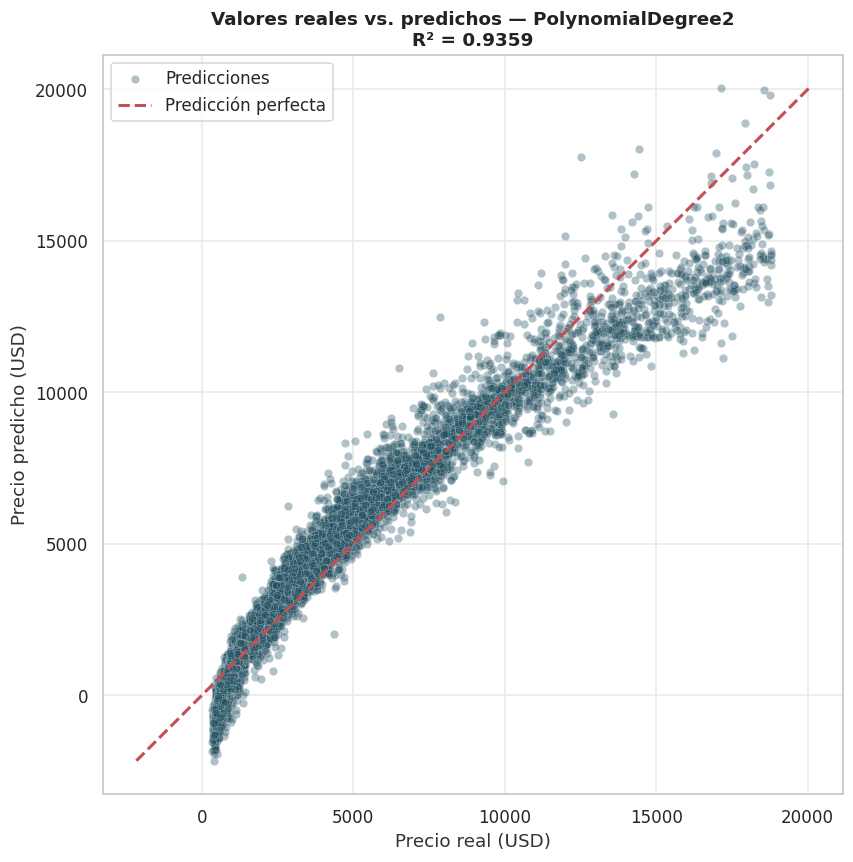

In [ ]:
best_model = results.loc[0, "Model"]
best_r2 = results.loc[0, "R2"]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(
    y_test_f, y_pred_poly, alpha=0.35, color=PRIMARY,
    edgecolors="white", linewidths=0.3, s=30, label="Predicciones",
)

lims = [
    min(y_test_f.min(), y_pred_poly.min()),
    max(y_test_f.max(), y_pred_poly.max()),
]

ax.plot(
    lims,
    lims,
    linestyle="--",
    color=SECONDARY,
    linewidth=2,
    label="Predicción perfecta",
)

ax.set_xlabel("Precio real (USD)")
ax.set_ylabel("Precio predicho (USD)")
ax.set_title(f"Valores reales vs. predichos — {best_model}\nR² = {best_r2:.4f}")
ax.legend(loc="upper left")
ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

10. Muestra la representación gráfica del pipeline para ubicar la posición de cada elemento dentro del flujo del modelo.

- Obtén los nombres de todas las columnas después del preprocesamiento (numéricas y dummies de categóricas).
- Extrae los nombres de las columnas polinómicas.
- Recupera los coeficientes y el intercepto del modelo de regresión lineal.
- Ordena los coeficientes por su valor absoluto para mostrar los 10 más importantes y da conclusiones sobre cómo los distintos factores influyen en el precio.


In [ ]:
from sklearn import set_config

In [ ]:
set_config(display='diagram')
display(pipeline_poly)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['carat', 'depth', 'table']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['cut', 'color',
                                                   'clarity'])])),
                ('poly',
                 PolynomialFeatures(include_bias=False, interaction_only=True)),
                ('regressor', LinearRegression())])

In [ ]:
feature_names = pipeline_poly.named_steps['preprocessor'].get_feature_names_out()
poly_features = pipeline_poly.named_steps['poly'].get_feature_names_out(feature_names)

In [ ]:
coefs = pipeline_poly.named_steps['regressor'].coef_

In [ ]:
df_coef = pd.DataFrame({"Feature": poly_features, "Coefficient": coefs})
df_coef_top10 = (
    df_coef.assign(Abs_Coef=df_coef["Coefficient"].abs())
    .sort_values("Abs_Coef", ascending=False)
    .head(10)
    .drop(columns="Abs_Coef")
    .round(4)
    .rename(columns={"Feature": "Variable", "Coefficient": "Coeficiente"})
)

In [ ]:
print("Top 10 coeficientes más importantes (por valor absoluto):")
display(df_coef_top10)

Top 10 coeficientes más importantes (por valor absoluto):


,Variable,Coeficiente
32,num__carat cat__clarity_IF,29287.9715
37,num__carat cat__clarity_VVS1,25482.4643
38,num__carat cat__clarity_VVS2,24694.1848
35,num__carat cat__clarity_VS1,21311.7321
0,num__carat,20444.5732
36,num__carat cat__clarity_VS2,20064.5513
21,num__carat num__table,17562.5051
33,num__carat cat__clarity_SI1,17098.3226
34,num__carat cat__clarity_SI2,15755.3520
31,num__carat cat__color_J,-8578.3737


## Pruebas del Polinomial



In [ ]:
num_pipeline = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=True))
])

In [ ]:
preprocessing_optimized = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', OneHotEncoder(drop='first'), ['cut', 'color', 'clarity'])
    ]
)

In [ ]:
pipeline_poly_optimized = Pipeline(steps=[
    ('preprocessor', preprocessing_optimized),
    ('regressor', LinearRegression())
])

In [ ]:
pipeline_poly_optimized.fit(X_train_f, y_train_f)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   MinMaxScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False,
                                                                                      interaction_only=True))]),
                                                  ['carat', 'depth', 'table']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['cut', 'color',
                                                   'clarity'])])),
                ('regressor', LinearRegression())])

In [ ]:
y_pred_poly_opt = pipeline_poly_optimized.predict(X_test_f)
results.loc[len(results)] = {
    'Model': 'PolynomialDegree2_Optimized',
    'RMSE': np.sqrt(mean_squared_error(y_test_f, y_pred_poly_opt)),
    'R2': r2_score(y_test_f, y_pred_poly_opt)
}

In [ ]:
results = results.sort_values(by="R2", ascending=False).reset_index(drop=True)
print("Modelos ordenados por R² (mejor primero)")
print(results.to_markdown(index=False))

Modelos ordenados por R² (mejor primero)
| Model                       |     RMSE |       R2 |
|:----------------------------|---------:|---------:|
| PolynomialDegree2           |  989.566 | 0.935859 |
| PolynomialDegree2_Optimized | 1130.83  | 0.91624  |
| OHE_MinMax                  | 1142.52  | 0.914499 |
| Ordinal_Robust              | 1216.82  | 0.903016 |
| Baseline                    | 1532.44  | 0.84618  |


**Conclusiones — sección 10**

Para la transformación Polinomial, se omitimieron las columnas creadas cuando se multiplican las categoricas al cuadrado.

El modelo **PolynomialDegree2** (mejor R²) confirma que el factor dominante del precio es el **tamaño del diamante**.

Los términos de interacción **`num__carat × claridad_*`** (IF, VVS1, VVS2, VS1, etc.) son positivos y elevados, lo que indica que, a igual peso, una mejor claridad incrementa el precio de forma importante. En contraste, la interacción **`num__carat × color_J`**  es negativa, señalando un descuento de precio asociado a este grado de color cuando el tamaño aumenta.

---

**Declaración de uso de IA**

*   Google. (2026). Gemini 3 Flash [Modelo de lenguaje grande], utilizado para la depuración de código y optimización de la estructura técnica de los resultados presentados. https://gemini.google.com/

*   OpenAI. (2026). *ChatGPT (basado en GPT-5.5)* [Modelo de lenguaje grande], utilizado para generación de código y depuración. https://chat.openai.com/
---